In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## I - Modèle de taux

1) Simulation d'un modèle de taux 

Pour se familiariser avec l'implémentation des calculs pour la simulation des processus stochastiques.
On ne considère pas le terme déterministe dans un premier temps (considéré nul)

In [78]:
# Paramètres du modèle G2++
r0 = 0.03  # taux court initial
T = 10  # horizon de simulation en années
N = 1000  # nombre de pas de temps
dt = T / N  # discrétisation du temps
t_grid = np.linspace(0, T, N + 1)

# Paramètres du modèle (à ajuster)
a, b = 0.1, 0.3  # coefficients de régression vers la moyenne
sigma, eta = 0.02, 0.01  # volatilités
rho = 0.5  # corrélation entre W1 et W2


In [74]:
# Génération des mouvements browniens corrélés W1 et W2
dW1 = np.random.normal(0, np.sqrt(dt), N)
dW2 = rho * dW1 + np.sqrt(1 - rho**2) * np.random.normal(0, np.sqrt(dt), N)

W1 = np.concatenate(([0], np.cumsum(dW1)))
W2 = np.concatenate(([0], np.cumsum(dW2)))



In [75]:
# Simulation des processus x(t) et y(t)
x = np.zeros(N + 1)
y = np.zeros(N + 1)

for i in range(1, N + 1):
    x[i] = x[i - 1] - a * x[i - 1] * dt + sigma * dW1[i - 1]
    y[i] = y[i - 1] - b * y[i - 1] * dt + eta * dW2[i - 1]



In [36]:
# Simulation de theta(t) (simplifiée sans courbe de taux initiale)
theta = np.zeros(N + 1)  # Pour l'instant, on prend une approximation à zéro

# Calcul du taux r(t)
r = x + y + theta



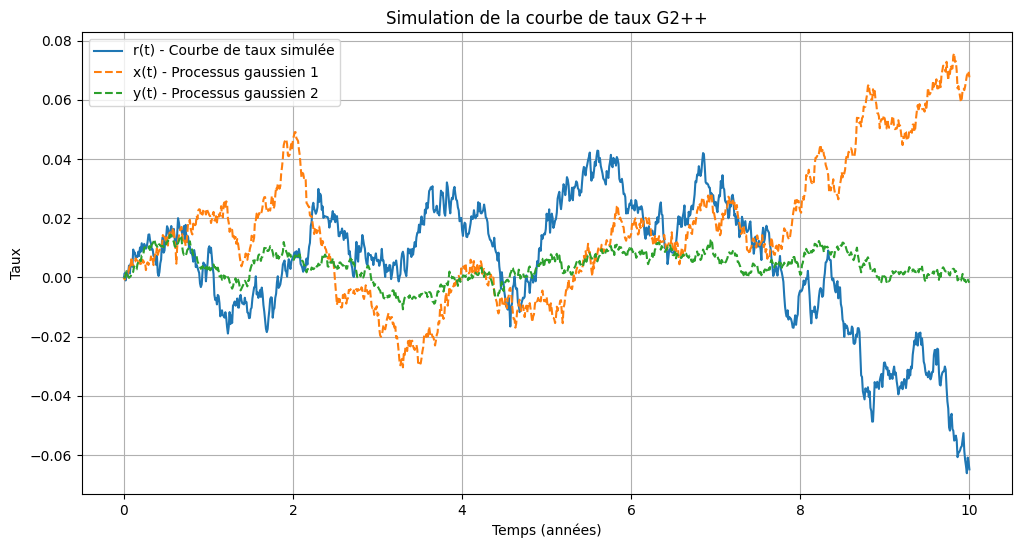

In [76]:
# Affichage des courbes
plt.figure(figsize=(12, 6))
plt.plot(t_grid, r, label='r(t) - Courbe de taux simulée')
plt.plot(t_grid, x, label='x(t) - Processus gaussien 1', linestyle='dashed')
plt.plot(t_grid, y, label='y(t) - Processus gaussien 2', linestyle='dashed')
plt.xlabel('Temps (années)')
plt.ylabel('Taux')
plt.legend()
plt.title('Simulation de la courbe de taux G2++')
plt.grid()
plt.show()

# Stockage des résultats dans un DataFrame
df_rates = pd.DataFrame({'Temps': t_grid, 'r(t)': r, 'x(t)': x, 'y(t)': y})


2) Ajout du terme déterministe

In [19]:
data = pd.ExcelFile("Input_GSE.xlsx")
data.sheet_names

['Cap Volatility', 'EIOPA Rate', 'EURIBOR Rate', 'Call Euro Stoxx 50']

In [27]:
# Read the data from the specified sheet
courbe_taux = pd.read_excel(data, sheet_name="EIOPA Rate", header=0)

courbe_taux = courbe_taux.iloc[:, :2]
courbe_taux = courbe_taux.dropna()

courbe_taux.head()

,Maturity,Rate
0,1,0.03911
1,2,0.03487
2,3,0.03263
3,4,0.03175
4,5,0.03149


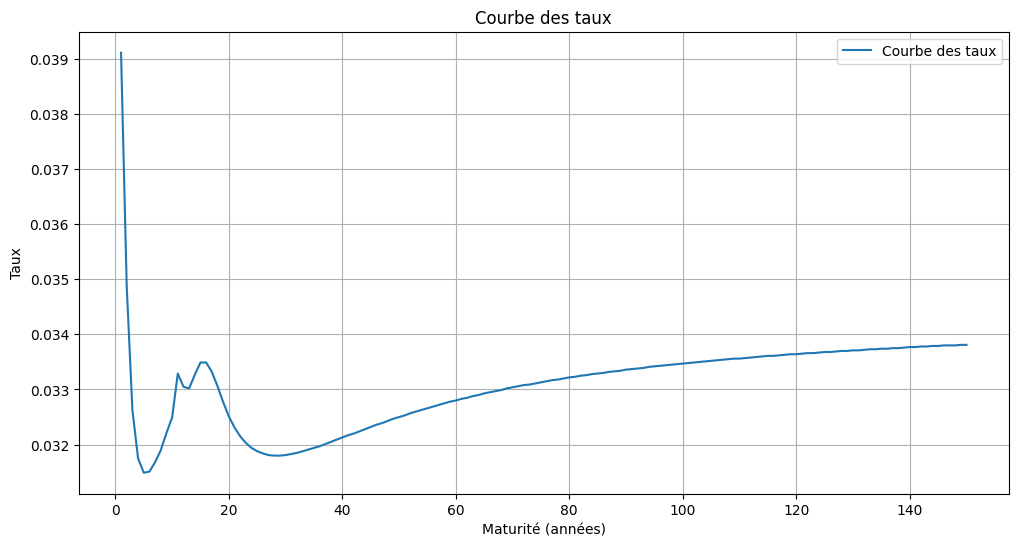

In [43]:
# Plot the yield curve
plt.figure(figsize=(12, 6))
plt.plot(courbe_taux['Maturity'], courbe_taux['Rate'], label='Courbe des taux')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux')
plt.legend()
plt.title('Courbe des taux')
plt.grid()
plt.show()

On a besoin pour coller à la courbe des taux de calculer les taux forward f(0,t)

In [51]:
maturities = courbe_taux["Maturity"].values
zero_coupon_rates = courbe_taux["Rate"].values

Methode NSS pour calculer le taux forward :  
$$
f(0,t) = \beta_0 + \beta_1 \cdot \alpha_1(t) + \beta_2 \cdot \alpha_2(t) + \beta_3 \cdot \alpha_3(t)
$$

avec :

$$
\alpha_1(t) = \frac{1 - e^{-t/\tau_1}}{t/\tau_1}
$$

$$
\alpha_2(t) = \alpha_1(t) - e^{-t/\tau_1}
$$

$$
\alpha_3(t) = \frac{1 - e^{-t/\tau_2}}{t/\tau_2} - e^{-t/\tau_2}
$$


In [52]:
from scipy.optimize import minimize

# Fonction qui calcule le taux forward f(0,t) selon le modèle NSS
def forward_0t(t, params):
    """
    Modèle de Nelson-Siegel-Svensson pour la courbe de taux forward instantanée.
    
    Arguments:
    t : float ou np.array : maturité en années
    params : list ou np.array : paramètres [beta0, beta1, beta2, beta3, tau1, tau2]
    
    Retourne:
    f(0,t) : taux forward instantané
    """
    beta0, beta1, beta2, beta3, tau1, tau2 = params

    alpha1 = (1 - np.exp(-t / tau1)) / (t / tau1)
    alpha2 = alpha1 - np.exp(-t / tau1)
    alpha3 = (1 - np.exp(-t / tau2)) / (t / tau2) - np.exp(-t / tau2)

    return beta0 + beta1 * alpha1 + beta2 * alpha2 + beta3 * alpha3

Minimisation par somme des écarts au carré

In [53]:
# Fonction d'objectif à minimiser pour calibrer les paramètres NSS
def NSS_objectif(params, maturities, rates):
    """
    Fonction d'erreur quadratique pour l'optimisation NSS.
    """
    return np.sum((forward_0t(maturities, params) - rates) ** 2)

In [54]:
# Estimation des paramètres initiaux (valeurs de départ pour l'optimisation)
initial_params = [0.03, -0.02, 0.02, -0.01, 2.0, 10.0]

# Exécution de l'optimisation
res = minimize(NSS_objectif, x0=initial_params, args=(maturities, zero_coupon_rates), method="Nelder-Mead")

# Récupération des paramètres optimisés
params_NSS = res.x

# Calcul de la courbe des taux forward calibrée avec les paramètres NSS optimisés
taux_forward_NSS = forward_0t(maturities, params_NSS)

C:\Users\massi\AppData\Local\Temp\ipykernel_27724\1566387235.py:17: RuntimeWarning: overflow encountered in exp
  alpha1 = (1 - np.exp(-t / tau1)) / (t / tau1)
C:\Users\massi\AppData\Local\Temp\ipykernel_27724\1566387235.py:18: RuntimeWarning: overflow encountered in exp
  alpha2 = alpha1 - np.exp(-t / tau1)
C:\Users\massi\AppData\Local\Temp\ipykernel_27724\1566387235.py:18: RuntimeWarning: invalid value encountered in subtract
  alpha2 = alpha1 - np.exp(-t / tau1)
C:\Users\massi\AppData\Local\Temp\ipykernel_27724\1984364784.py:6: RuntimeWarning: overflow encountered in square
  return np.sum((forward_0t(maturities, params) - rates) ** 2)


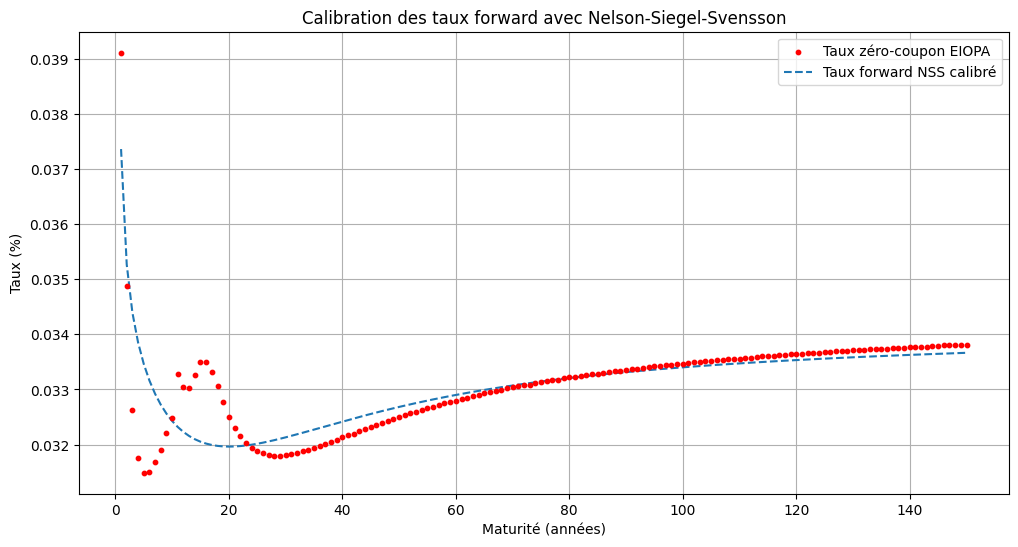

In [56]:
# Affichage des résultats
plt.figure(figsize=(12, 6))
plt.scatter(maturities, zero_coupon_rates, color='red', label="Taux zéro-coupon EIOPA", zorder=3, s=10)
plt.plot(maturities, taux_forward_NSS, label="Taux forward NSS calibré", linestyle='dashed', zorder=2)
plt.xlabel("Maturité (années)")
plt.ylabel("Taux (%)")
plt.legend()
plt.title("Calibration des taux forward avec Nelson-Siegel-Svensson")
plt.grid()
plt.show()

# Stockage des résultats
df_taux_forward = pd.DataFrame({'Maturité': maturities, 'Taux Zéro-Coupon': zero_coupon_rates, 'Taux Forward NSS': taux_forward_NSS})

Calcul de la partie déterministe avec la formule :  
$$
\theta(t) = \frac{\partial f(0,t)}{\partial t} + a f(0,t) + b f(0,t) 
- \frac{\sigma^2}{2a} (1 - e^{-2at}) 
- \frac{\eta^2}{2b} (1 - e^{-2bt}) 
- \frac{\rho \sigma \eta}{a+b} (1 - e^{-(a+b)t})
$$


In [79]:
theta = [r0]
for t in t_grid[1:]:
    
    taux_forward = forward_0t(t, params_NSS)
    df_dt = 0

    # Calcul des termes correctifs
    terme1 = - (sigma**2 / (2 * a)) * (1 - np.exp(-2 * a * t))
    terme2 = - (eta**2 / (2 * b)) * (1 - np.exp(-2 * b * t))
    terme3 = - (rho * sigma * eta / (a + b)) * (1 - np.exp(-(a + b) * t))

    # Calcul de θ(t)
    theta_t = df_dt + a * taux_forward + b * taux_forward + terme1 + terme2 + terme3

    theta.append(theta_t)

theta

[0.03,
 np.float64(0.015757602067022668),
 np.float64(0.016947910123770636),
 np.float64(0.017890827302275574),
 np.float64(0.018627703367119344),
 np.float64(0.01919340076839869),
 np.float64(0.01961728467679076),
 np.float64(0.01992406411773368),
 np.float64(0.02013450640634353),
 np.float64(0.02026604379270382),
 np.float64(0.020333288421456812),
 np.float64(0.0203484693185651),
 np.float64(0.020321803080587814),
 np.float64(0.020261808205709147),
 np.float64(0.020175571526616625),
 np.float64(0.020068973945238662),
 np.float64(0.01994688159598817),
 np.float64(0.019813307649944302),
 np.float64(0.019671549193835004),
 np.float64(0.01952430295470544),
 np.float64(0.019373763076683932),
 np.float64(0.019221703675713575),
 np.float64(0.0190695484890822),
 np.float64(0.01891842958846438),
 np.float64(0.018769236828961696),
 np.float64(0.018622659454595892),
 np.float64(0.018479221066317036),
 np.float64(0.01833930897624805),
 np.float64(0.01820319881683369),
 np.float64(0.0180710751417

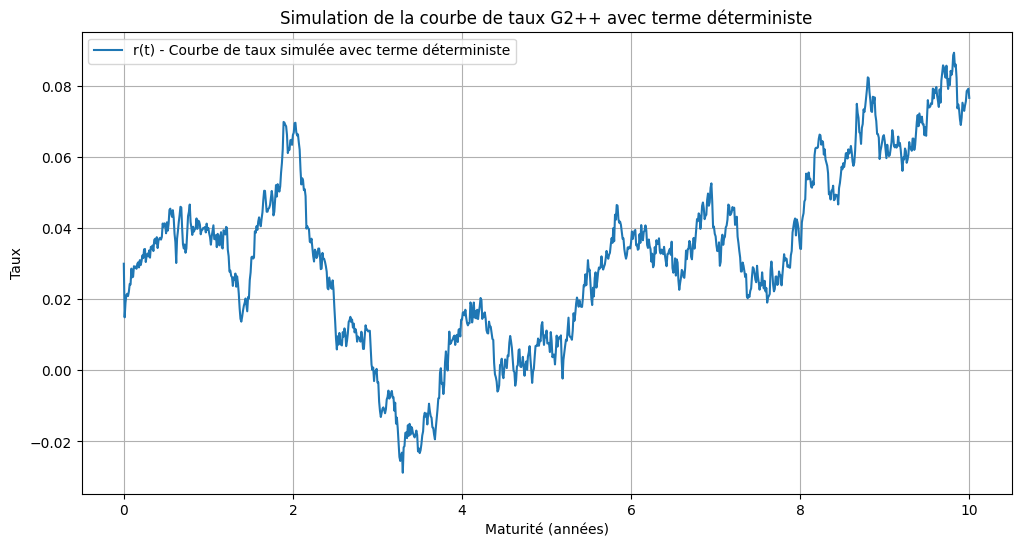

In [80]:
r_2 = x + y + theta
plt.figure(figsize=(12, 6))
plt.plot(t_grid, r_2, label='r(t) - Courbe de taux simulée avec terme déterministe')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux')
plt.legend()
plt.title('Simulation de la courbe de taux G2++ avec terme déterministe')
plt.grid()
plt.show()